**Various checks and numerical tests for all models**

# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from utils import set_matplotlib_style, non_uniform_grid
from heston import HestonModel, get_params_heston
from rough_heston import RoughHestonModel, get_params_rough_heston
from rough_bergomi import RoughBergomiModel

set_matplotlib_style()
SEED = 1234

## Comparison finite difference and characteristic function

We compare SSR, ATM skew computed via finite difference and characteristic 
function methods for the Heston and rough Heston models.

In [3]:
Ts = non_uniform_grid(1e-3, 3, 15, 1.5)

In [4]:
heston = HestonModel(get_params_heston(id=1))
print(heston)

HestonModel with parameters:
kappa=1.0, rho=-0.8, eta=0.6, vbar=0.04, v=0.04, s0=1.0


In [5]:
params, xi0 = get_params_rough_heston(id=1)
n_pade = 5
n_quad = 40
rheston = RoughHestonModel(params=params, xi0=xi0)
print(rheston)

RoughHestonModel with parameters:
eta=0.4, H=0.05, kappa=1.0, rho=-0.65, s0=1.0


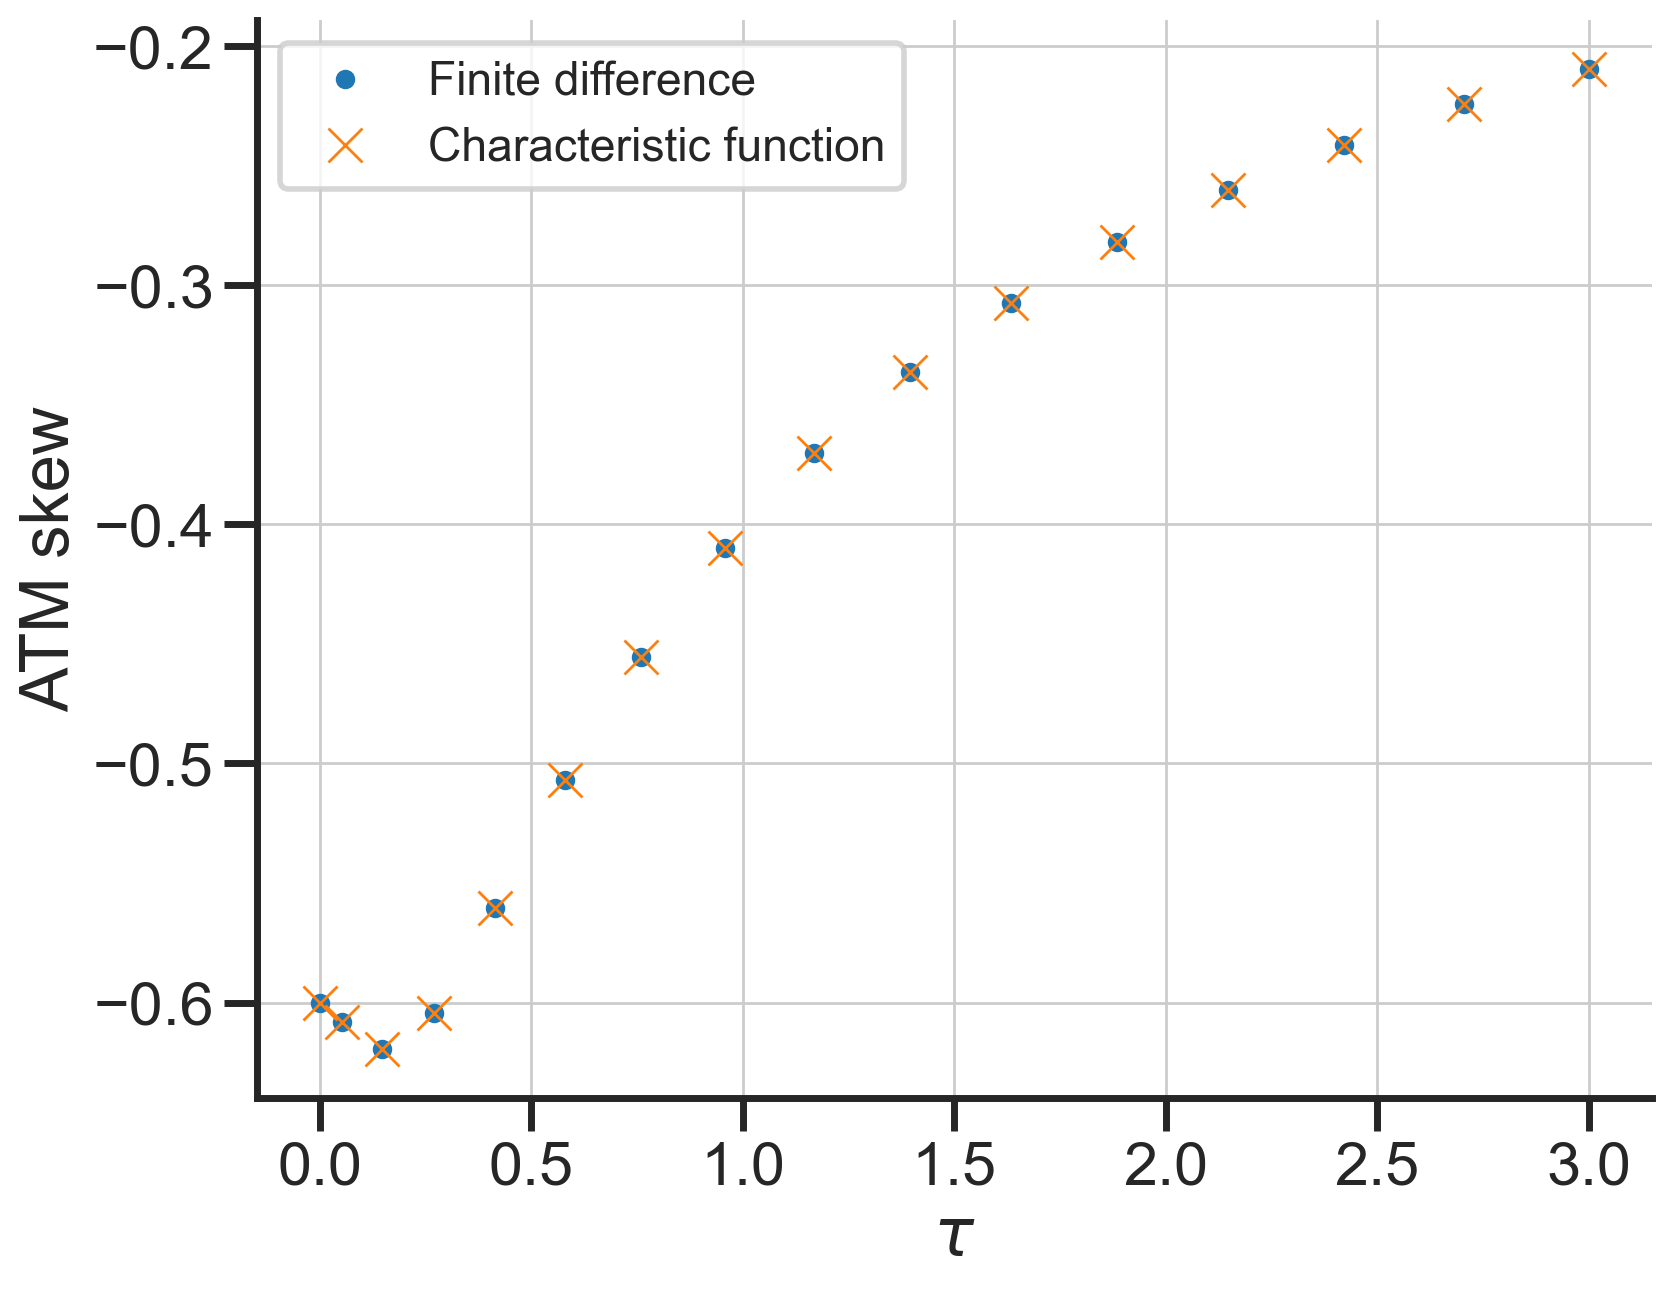

In [6]:
# atm skew
atm_skew_fd = heston.atm_skew_fd(Ts, eps=1e-4)
atm_skew_cf = heston.atm_skew_cf(Ts)

fig, ax = plt.subplots()
ax.plot(Ts, atm_skew_fd, ".", label="Finite difference")
ax.plot(Ts, atm_skew_cf, "x", label="Characteristic function")
ax.legend()
ax.set_xlabel(r"$\tau$")
ax.set_ylabel("ATM skew")
plt.show()

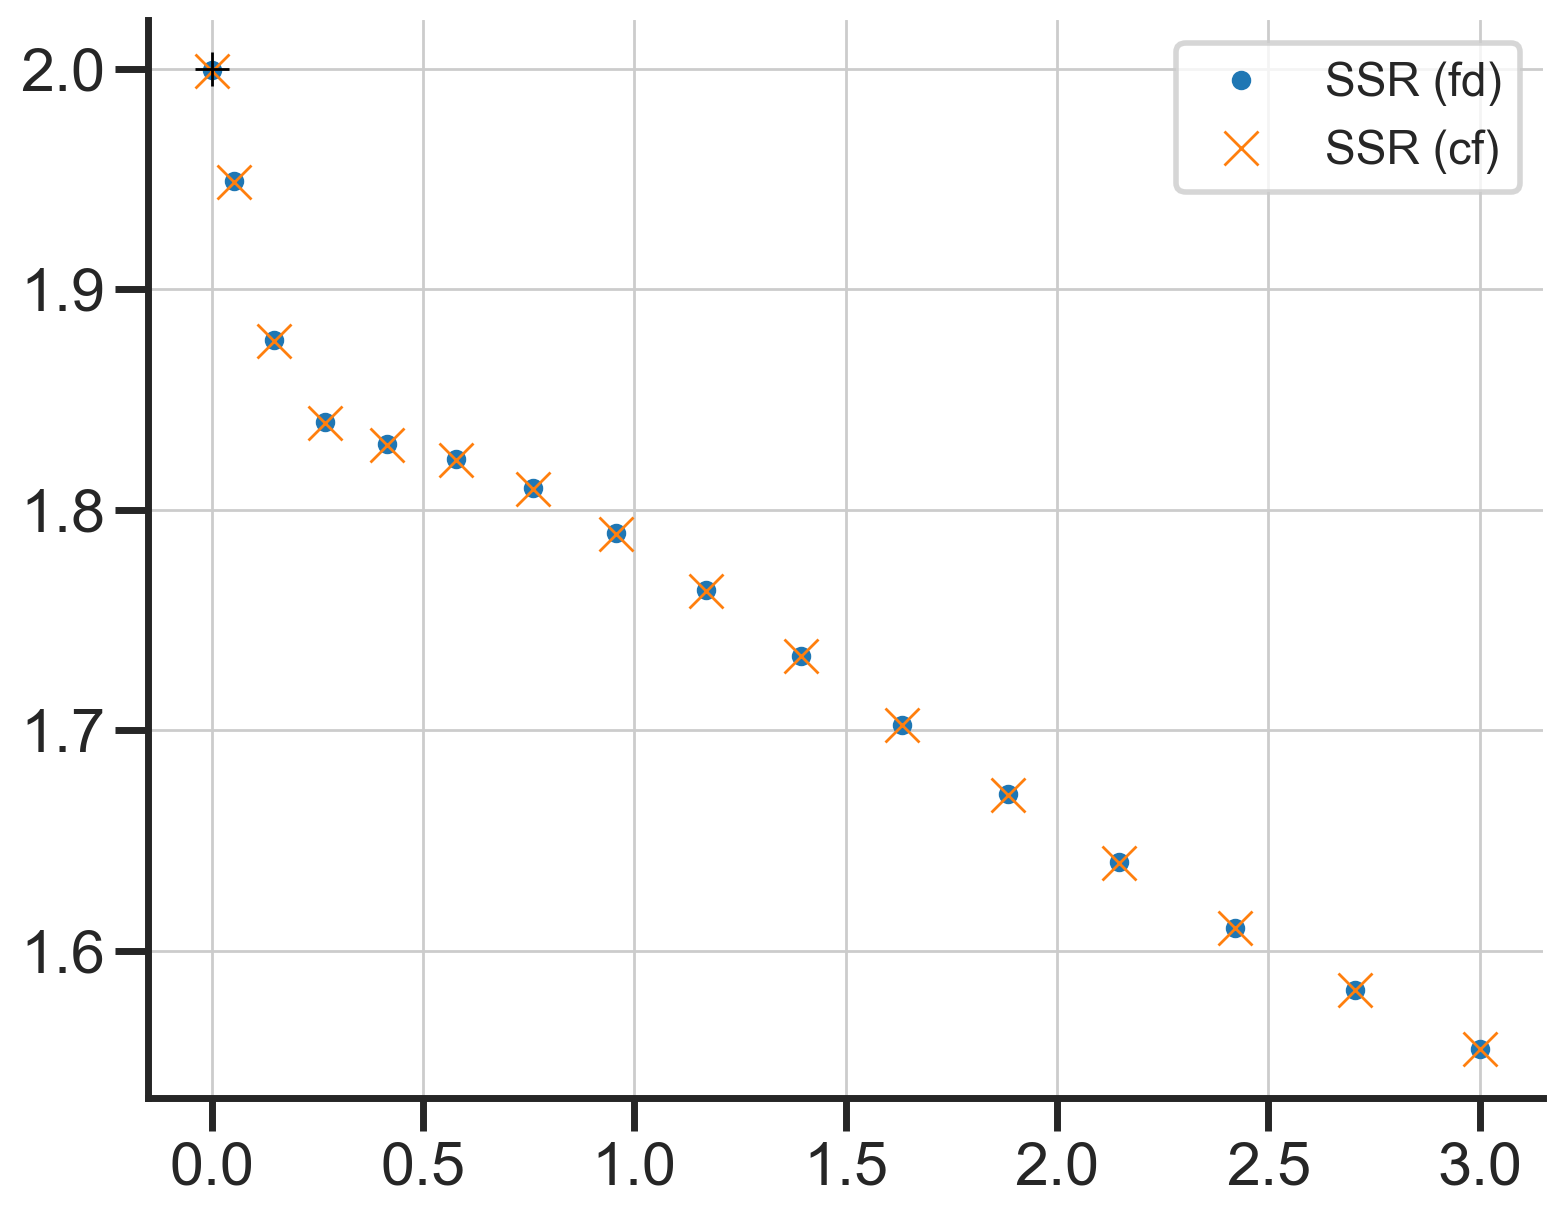

In [7]:
# SSR
ssr_fd = heston.ssr_fd(Ts, 1e-4)
ssr_cf = heston.ssr_cf(Ts)

fig, ax = plt.subplots()
ax.plot(Ts, ssr_fd, ".", markersize=12, label="SSR (fd)")
ax.plot(Ts, ssr_cf, "x", markersize=12, label="SSR (cf)")
ax.plot([0], [2], "+k")
ax.legend()
plt.show()

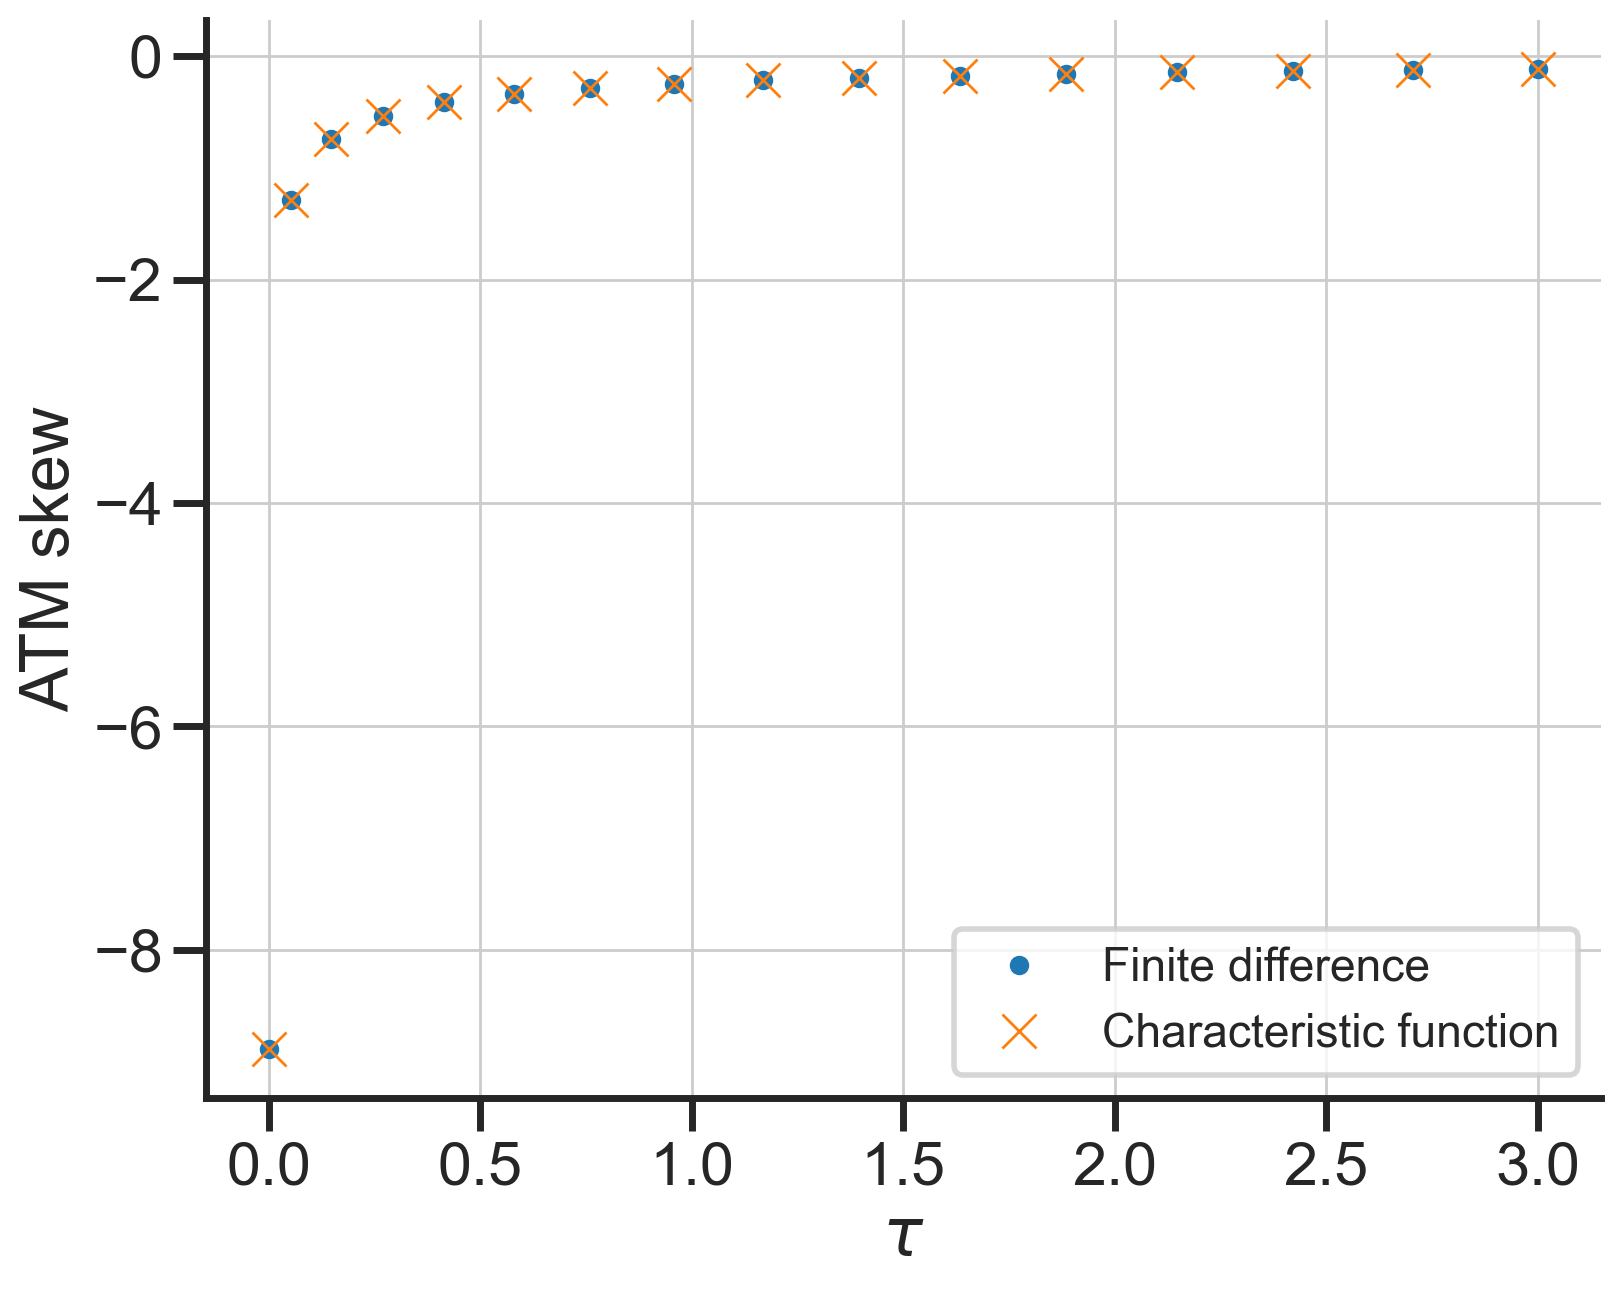

In [8]:
# atm skew
atm_skew_fd = rheston.atm_skew_fd(Ts, n_pade=n_pade, n_quad=n_quad, eps=1e-4)
atm_skew_cf = rheston.atm_skew_cf(Ts, n_pade=n_pade, n_quad=n_quad)

fig, ax = plt.subplots()
ax.plot(Ts, atm_skew_fd, ".", label="Finite difference")
ax.plot(Ts, atm_skew_cf, "x", label="Characteristic function")
ax.legend()
ax.set_xlabel(r"$\tau$")
ax.set_ylabel("ATM skew")
plt.show()

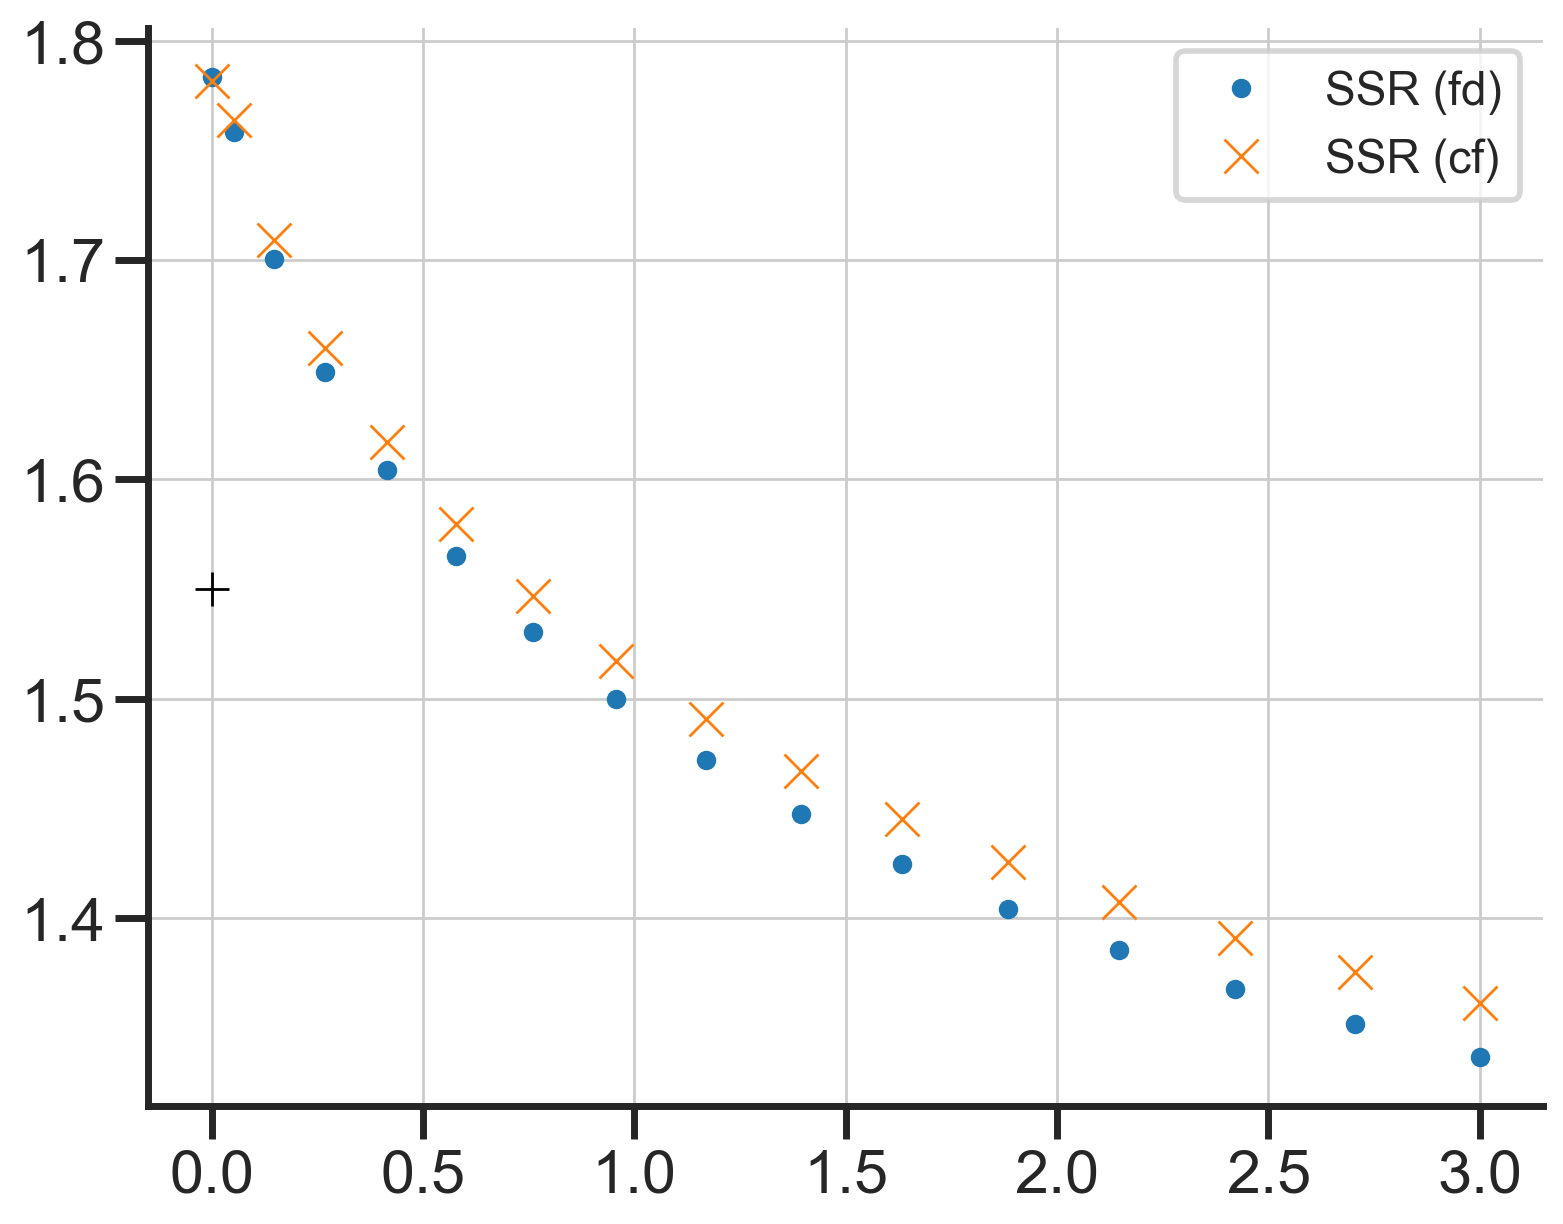

In [9]:
# SSR
ssr_fd = rheston.ssr_fd(Ts, n_pade=n_pade, n_quad=n_quad, eps=1e-4)
ssr_cf = rheston.ssr_cf(
    Ts,
    n_pade=n_pade,
    n_quad=n_quad,
)

fig, ax = plt.subplots()
ax.plot(Ts, ssr_fd, ".", markersize=12, label="SSR (fd)")
ax.plot(Ts, ssr_cf, "x", markersize=12, label="SSR (cf)")
ax.plot([0], [rheston.H + 3 / 2], "+k")
ax.legend()
plt.show()

## ATM skew

Compare ATM skew via finite difference or Monte Carlo (via digit pricing) with and without conditioning.

In [10]:
params = {"eta": 1.9, "H": 0.3, "rho": -0.7}
xi0 = lambda t: 0.2**2 * np.ones_like(t)
rbergomi = RoughBergomiModel(params=params, xi0=xi0)

## Implied volatility

We reproduce Figures 8.2 and 8.3 with parameters from Table 8.2 of _Bergomi (2016) - Stochastic Volatility Modeling._

In [11]:
from two_bergomi import TwoFactorBergomiModel, get_params_two_factor_bergomi


params, xi0 = get_params_two_factor_bergomi(id=1)
two_bergomi = TwoFactorBergomiModel(params=params, xi0=xi0)

In [12]:
two_bergomi

TwoFactorBergomiModel with parameters:
w=3.48, k1=5.25, k2=0.28, theta=0.245, rho12=0.0, rhoS1=-0.759, rhoS2=-0.487, s0=1.0

In [13]:
n_mc = 10**5
n_disc = 200

T = 1 / 12
ks = np.log(np.linspace(0.85, 1.15, 11))

In [14]:
impvols = two_bergomi.impvol(
    k=ks, T=T, n_mc=n_mc, n_disc=n_disc, seed=SEED, conditioning=False
)
impvols_cond = two_bergomi.impvol(
    k=ks, T=T, n_mc=n_mc, n_disc=n_disc, seed=SEED, conditioning=True
)

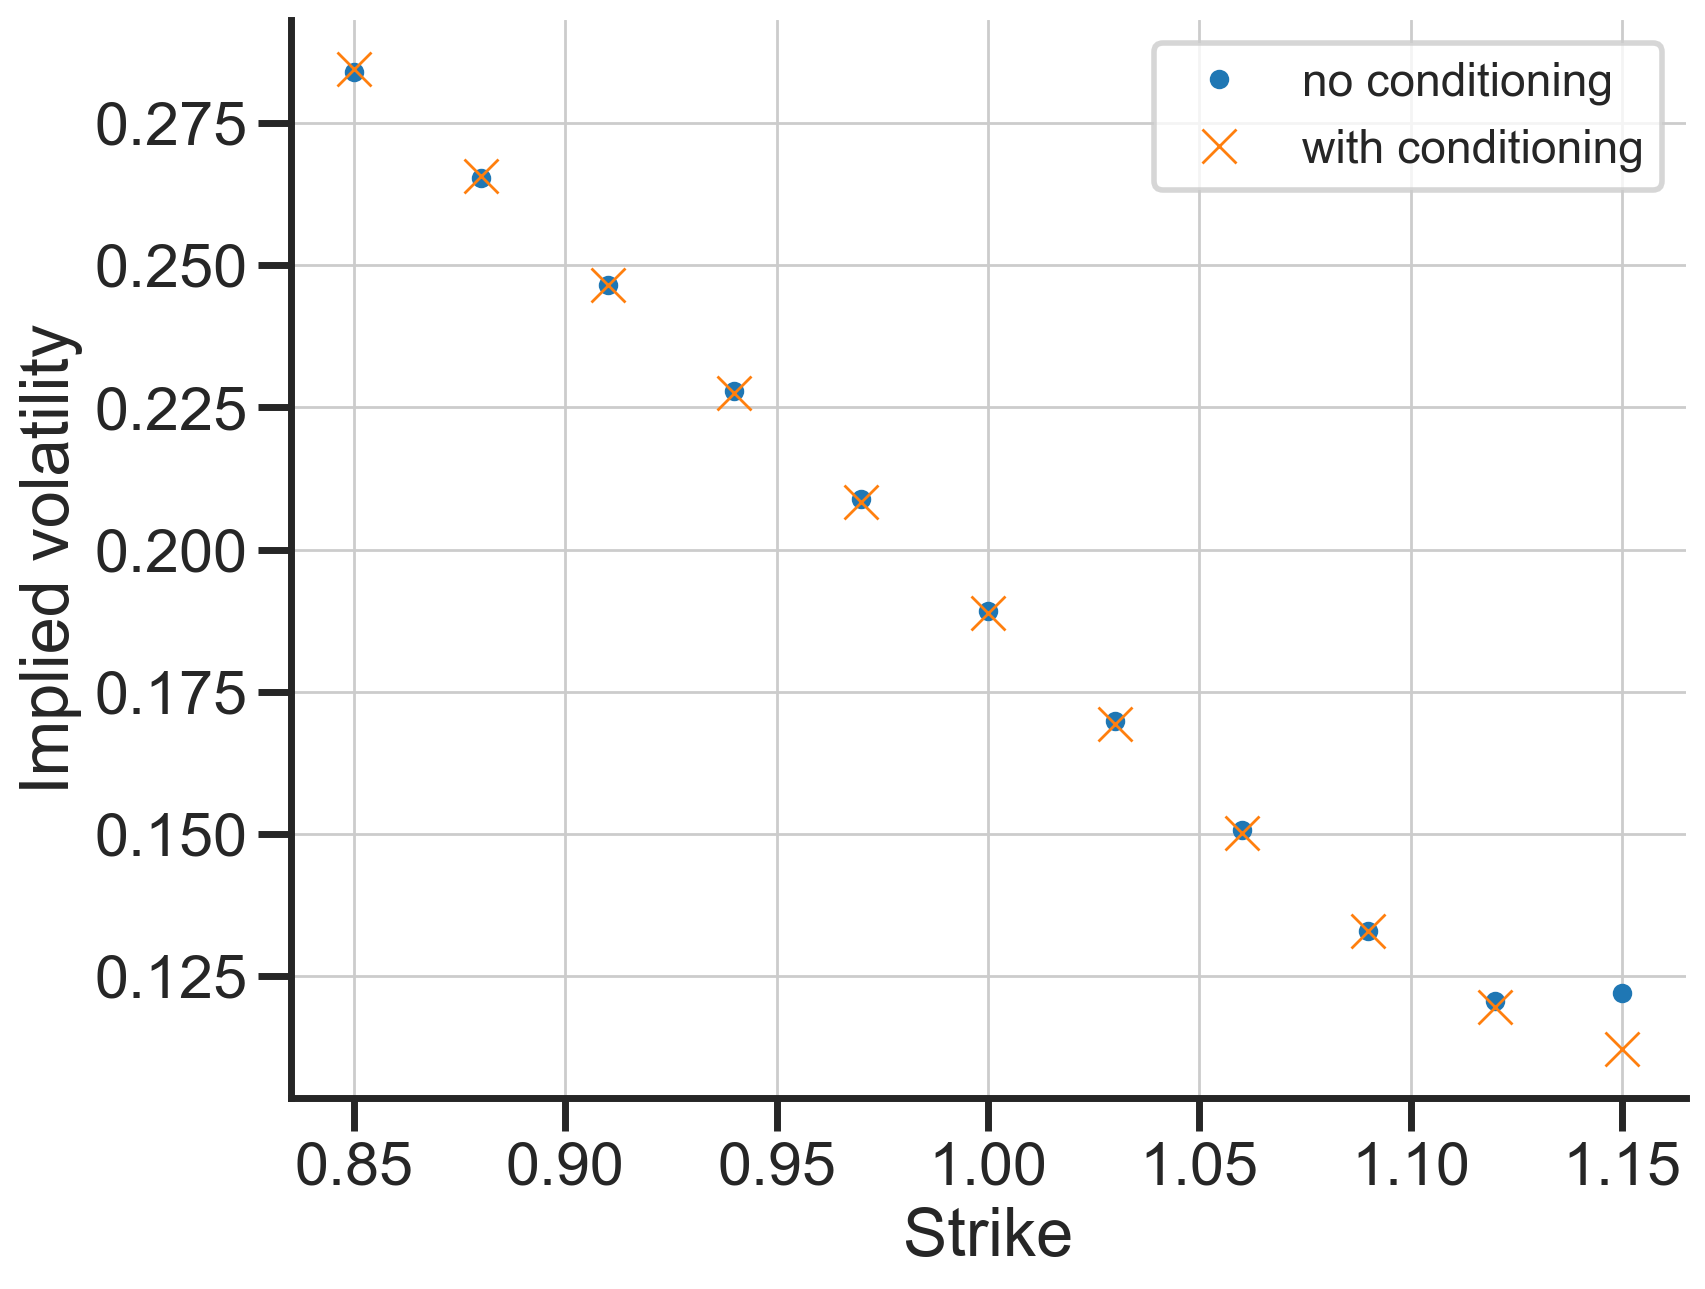

In [15]:
fig, ax = plt.subplots()
ax.plot(np.exp(ks), impvols, ".", label="no conditioning")
ax.plot(np.exp(ks), impvols_cond, "x", label="with conditioning")
ax.set_xlabel("Strike")
ax.set_ylabel("Implied volatility")
ax.legend()
plt.show()

# Two-factor Bergomi

## SSR

In [16]:
params, xi0 = get_params_two_factor_bergomi(id=1)
two_bergomi = TwoFactorBergomiModel(params=params, xi0=xi0)

In [17]:
Ts = np.linspace(1e-3, 3, 5)
n_mc = 10**5
n_disc = 100
eps_ssr = 1e-3

tab_t = np.linspace(0, 1.0, n_disc + 1)

x1_shifted = two_bergomi.simulate_mc(
    tab_t,
    n_mc=n_mc,
    seed=SEED,
    eps_ssr=eps_ssr,
)

## ATM skew

In [18]:
params, xi0 = get_params_two_factor_bergomi(id=1)
two_bergomi = TwoFactorBergomiModel(params=params, xi0=xi0)
print(two_bergomi)

TwoFactorBergomiModel with parameters:
w=3.48, k1=5.25, k2=0.28, theta=0.245, rho12=0.0, rhoS1=-0.759, rhoS2=-0.487, s0=1.0


In [19]:
Ts = np.linspace(1e-3, 3, 10)
n_mc = 10**5
n_disc = 100

atm_skew = np.zeros_like(Ts)
atm_skew_cond = np.zeros_like(Ts)

for i, Ti in enumerate(Ts):
    atm_skew[i] = two_bergomi.impvol(
        k=0,
        T=Ti,
        n_mc=n_mc,
        n_disc=n_disc,
        seed=SEED,
        return_skew=True,
        conditioning=False,
    )[1].item()
    atm_skew_cond[i] = two_bergomi.impvol(
        k=0,
        T=Ti,
        n_mc=n_mc,
        n_disc=n_disc,
        seed=SEED,
        return_skew=True,
        conditioning=True,
    )[1].item()

In [22]:
n_quad = 30
Ts_bg = np.linspace(Ts[0], Ts[-1], 100)
out_bg = two_bergomi.ssr_bg_all(Ts_bg, n_quad=n_quad)

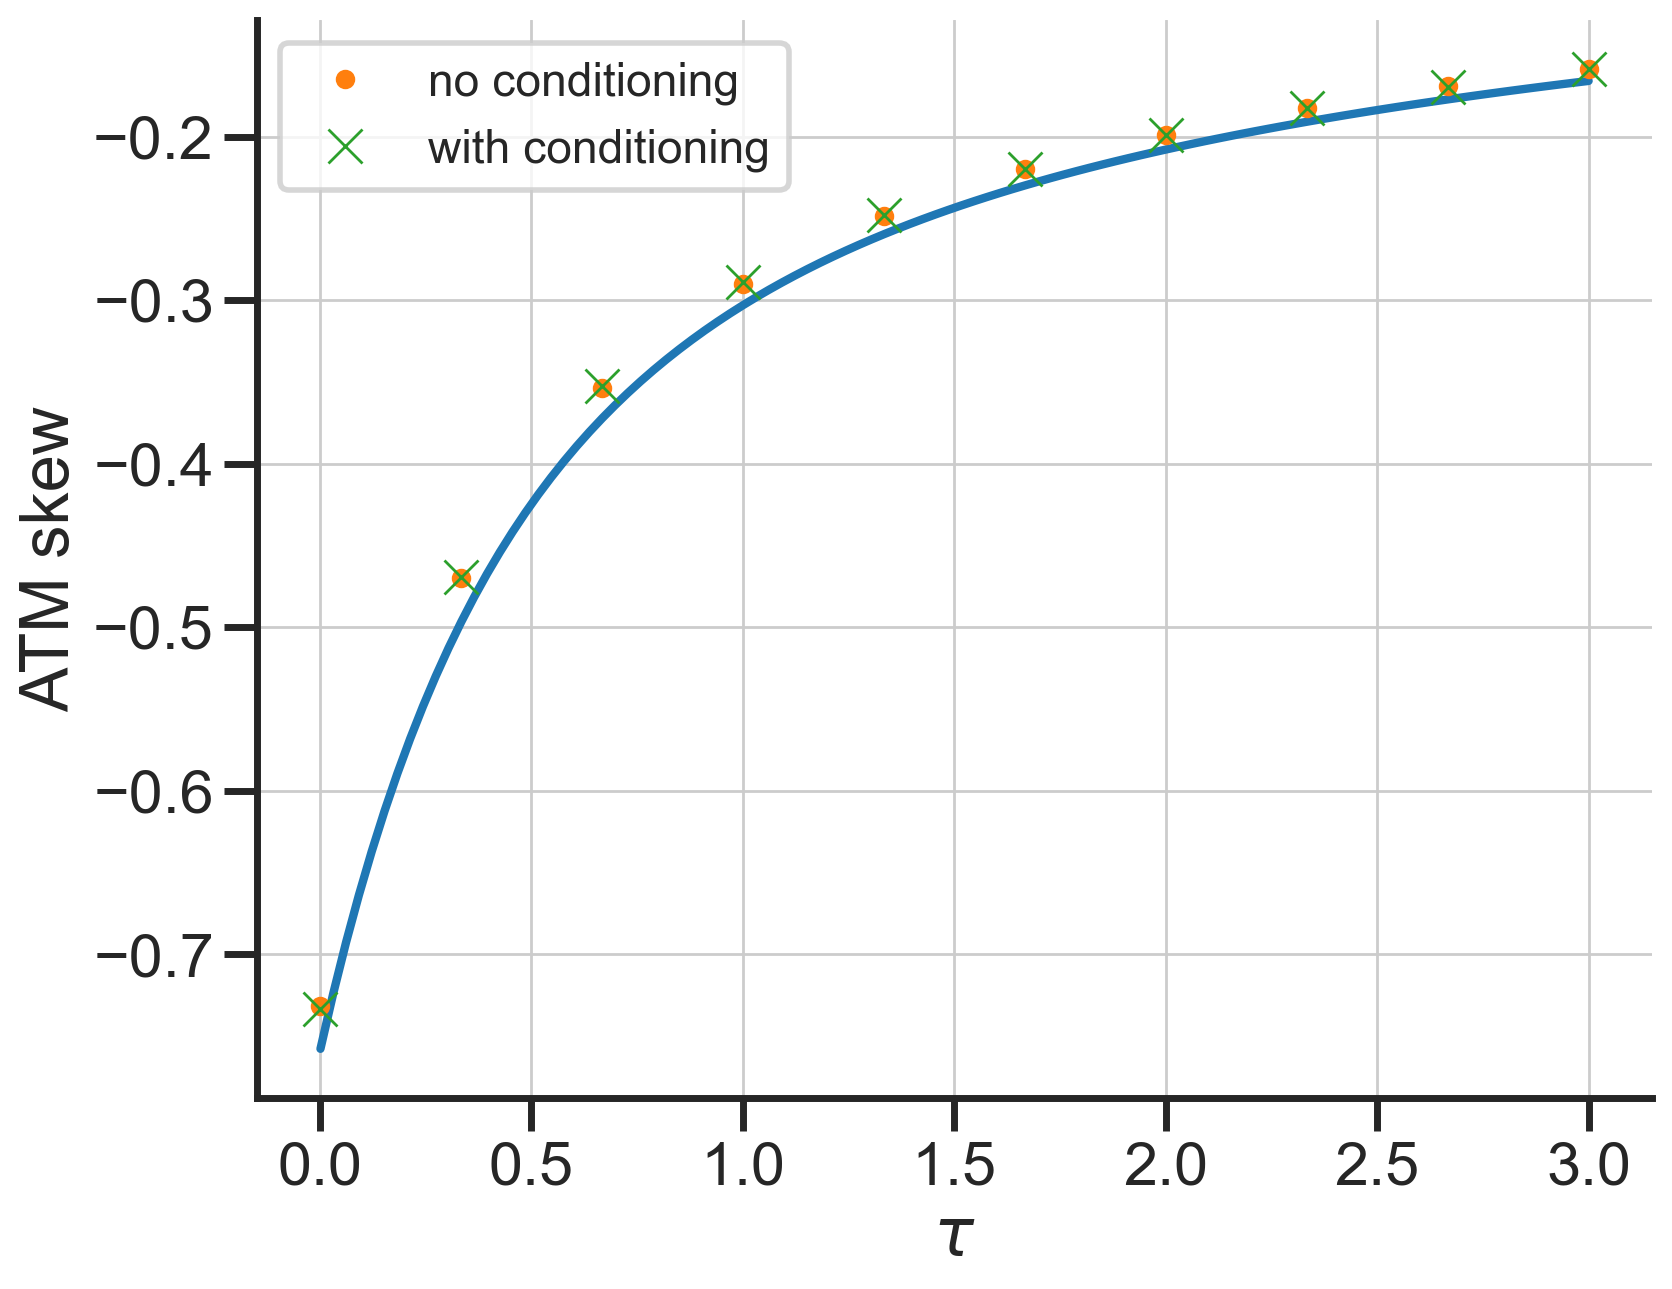

In [23]:
fig, ax = plt.subplots()
ax.plot(Ts_bg, out_bg["atm_skew_1"] + out_bg["atm_skew_2"], "-")
ax.plot(Ts, atm_skew, ".", label="no conditioning")
ax.plot(Ts, atm_skew_cond, "x", label="with conditioning")
ax.legend()
ax.set_xlabel(r"$\tau$")
ax.set_ylabel("ATM skew")
plt.show()

In [24]:
Ts = non_uniform_grid(7 / 365, 3, 15, 1.5)

atm_impvol = np.zeros_like(Ts)
atm_skew = np.zeros_like(Ts)

atm_impvol_cond = np.zeros_like(Ts)
atm_skew_cond = np.zeros_like(Ts)

for i, T in enumerate(Ts):
    print(f"Ti={T:.4f}")
    out = rbergomi.impvol(
        k=0,
        T=T,
        n_mc=n_mc,
        n_disc=n_disc,
        seed=SEED,
        return_skew=True,
        conditioning=False,
    )
    atm_impvol[i], atm_skew[i] = out[0][0], out[1][0]
    out_cond = rbergomi.impvol(
        k=0,
        T=T,
        n_mc=n_mc,
        n_disc=n_disc,
        seed=SEED,
        return_skew=True,
        conditioning=True,
    )
    atm_impvol_cond[i], atm_skew_cond[i] = out_cond[0][0], out_cond[1][0]

Ti=0.0192
Ti=0.0705
Ti=0.1643
Ti=0.2858
Ti=0.4297
Ti=0.5928
Ti=0.7733
Ti=0.9694
Ti=1.1802
Ti=1.4045
Ti=1.6417
Ti=1.8911
Ti=2.1521
Ti=2.4242
Ti=2.7069
Ti=3.0000


In [25]:
# ATM skew BG expansion
Ts_bg = np.linspace(Ts[0], Ts[-1], 500)
out_bg = rbergomi.ssr_bg_all(Ts, n_quad=20)

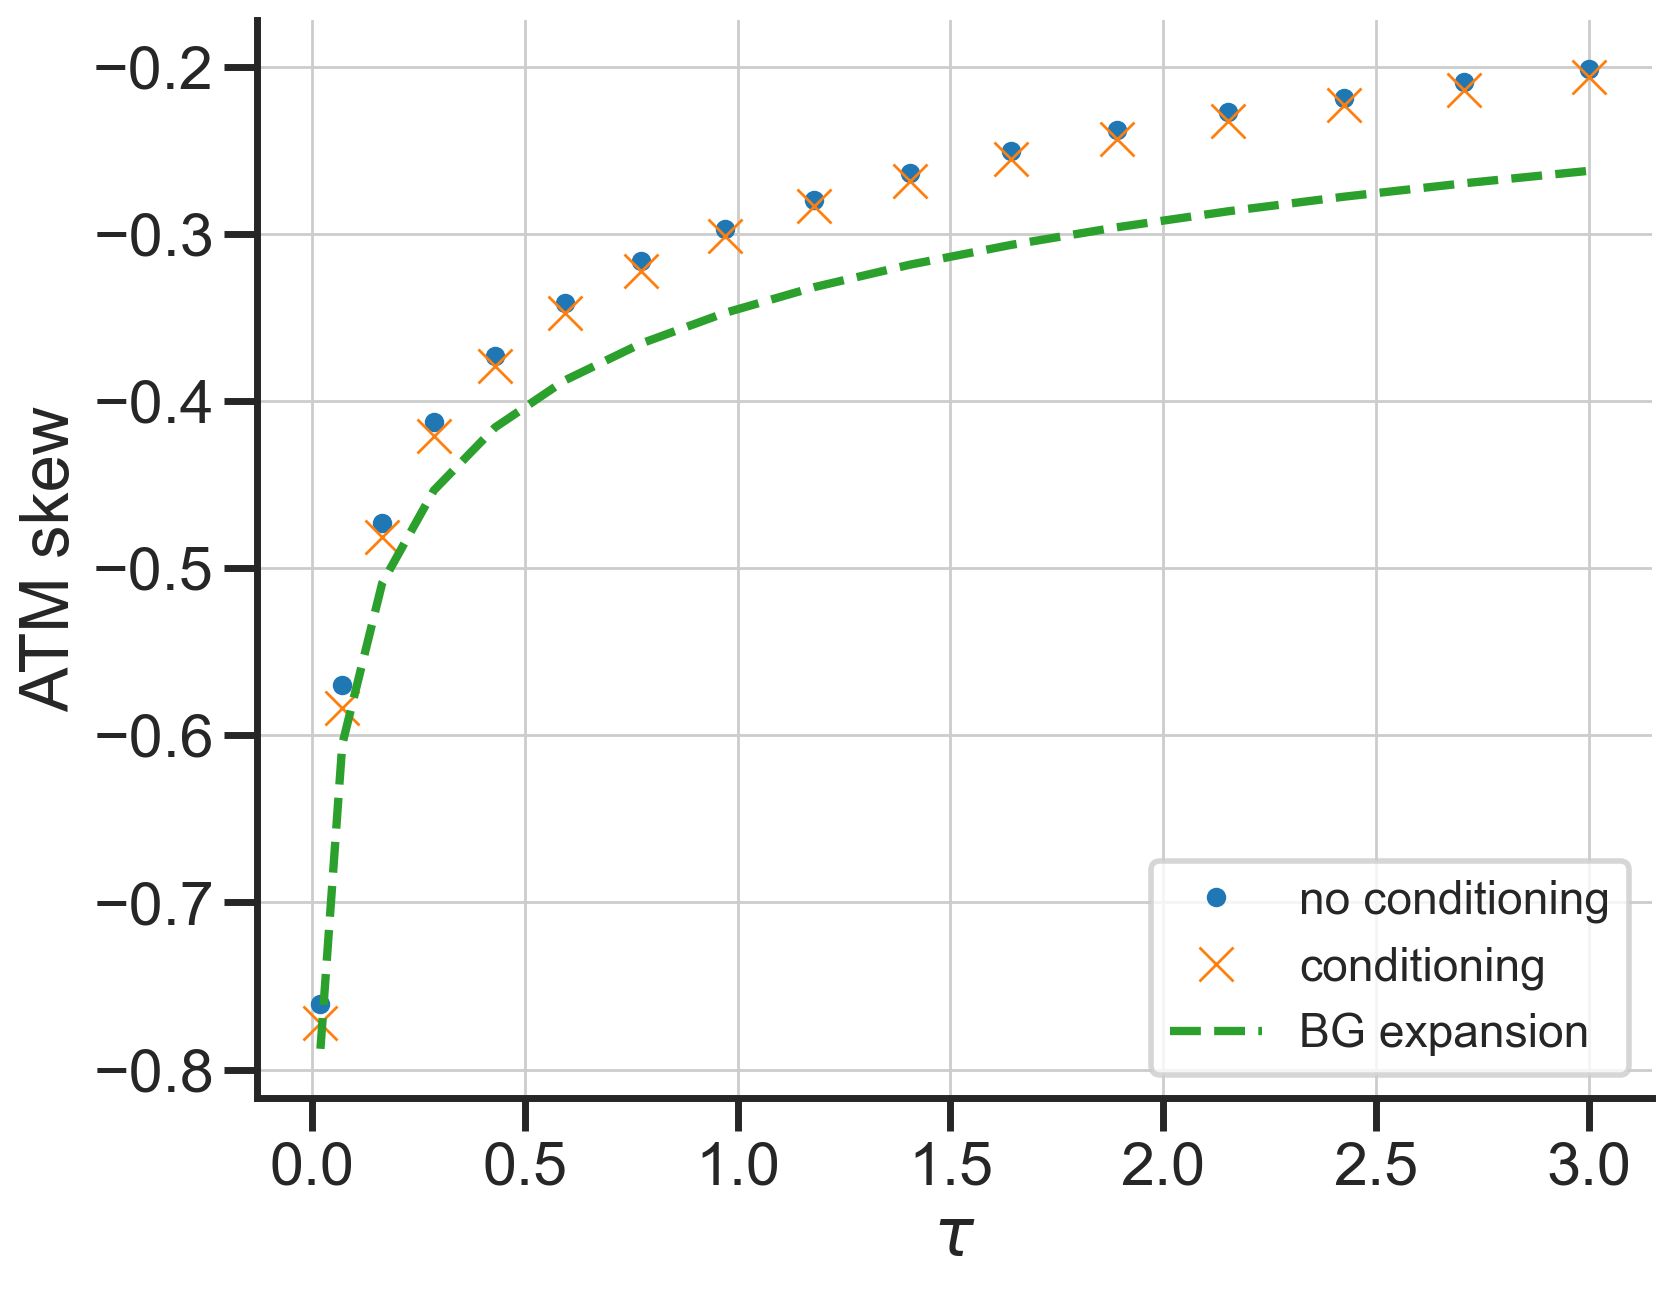

In [26]:
fig, ax = plt.subplots()
ax.plot(Ts, atm_skew, ".", label="no conditioning")
ax.plot(Ts, atm_skew_cond, "x", label="conditioning")
ax.plot(Ts, out_bg["atm_skew_1"] + out_bg["atm_skew_2"], "--", label="BG expansion")
ax.set_xlabel(r"$\tau$")
ax.set_ylabel("ATM skew")
ax.legend()
plt.show()